# Técnicas Supervisionadas de Classificação 

### Vamos ao nosso desafio!!!

    Churn Prediction
    Uma determinada empresa financeira deseja uma solução de IA que indique quais clientes irão cancelar o serviço 
    em um futuro próximo.


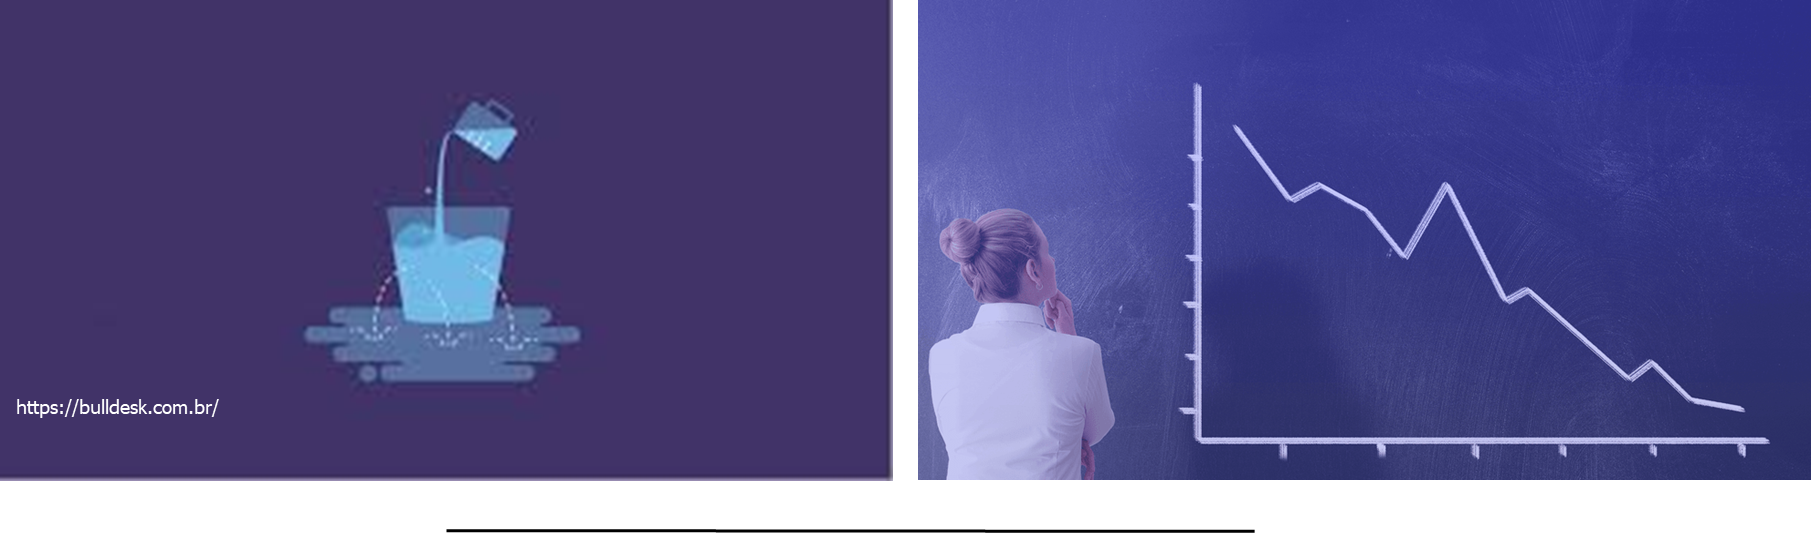


# Prever se uma pessoa vai fechar a conta no banco

Dataset: https://www.kaggle.com/shrutimechlearn/churn-modelling





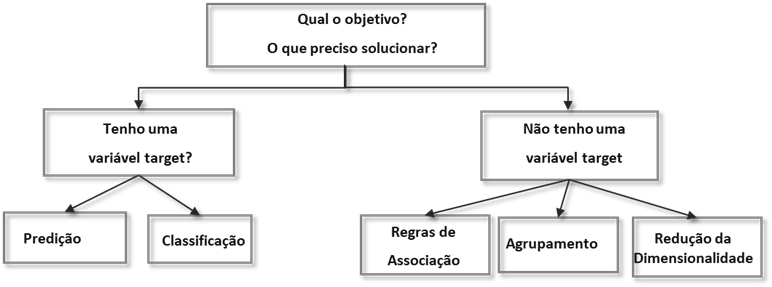





     As técnicas Supervisionadas de Predição: Se aplica quando a variável de interesse/target é numérica quantitativa
     
     As técnicas Supervisionadas de Classificação: Se aplica quando a variável de interesse/target é categórica 

    Base de dados: 
    CostumerId:  código numérico que identifica o cliente de forma única
    Surname: Sobrenome do cliente
    CreditScore: Score creditício do cliente
    Geography: Localidade do cliente
    Age: idade do cliente
    Gender: Identificação do gênero do cliente
    Tenure: Período de fechamento de uma empréstimo
    Balance: Valor de saldo em conta
    NumOfProducts: número de produtos que o cliente tem na instituição
    HasCrCard: Se pussui cartão de crédito
    IsActivemember: Se é membro ativo da plataforma da instituição
    EstimatedSalary: Salário estimado ao ano
    Exited: se saiu da base de clientes


In [1]:
# Importar as bibliotecas

import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline

# Com esse comando "%matplotlib inline", a saída dos comandos de plotagem é exibida inline em frontends como o notebook Jupyter, 
# diretamente abaixo da célula de código que o produziu.
# Os gráficos resultantes também serão armazenados no documento do caderno.”

# https://ipython.readthedocs.io/en/stable/interactive/plotting.html



import sklearn
 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,export_graphviz
from sklearn import preprocessing
from sklearn import metrics 
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import roc_curve



import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


  Vamos usar as bibliotecas do scikit Learn
  

https://scikit-learn.org/stable/getting_started.html


In [3]:
# Importar os dados
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


   ==> Em uma primeira avaliação das variáveis já encontramos a nossa variável target: Exited

In [5]:
# dataset info to find columns and count of the data 
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
# excluindo variáveis que não são necessárias
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)
df.head() 

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
# Avaliando a quantidade de NA´s (missing)
pd.DataFrame(zip(df.isnull().sum(), df.isnull().sum()/len(df)), columns=['Count', 'Proportion'], index=df.columns)


,Count,Proportion
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0
HasCrCard,0,0.0
IsActiveMember,0,0.0
EstimatedSalary,0,0.0


In [11]:
# algumas analises descritivas 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


In [13]:
# Variável target: "Exited" : Quantos Churn
(df.Exited.value_counts() / df.shape[0]) * 100

Exited
0    79.63
1    20.37
Name: count, dtype: float64

  Agora é a vez de avaliar as variáveis preditoras!!
  Começaremos com as variáveis numéricas

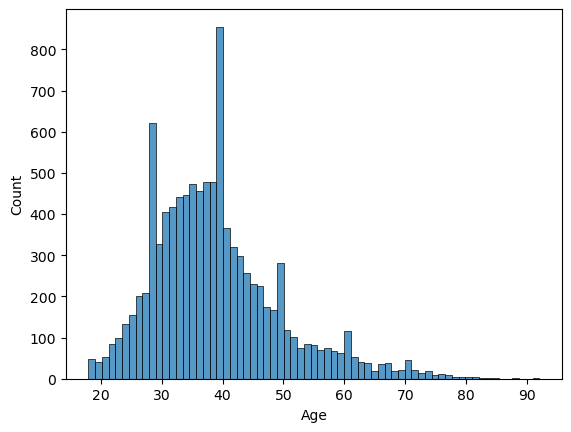

In [15]:
# Variável preditora: Age

sb.histplot(data=df, x="Age");

      ==> avaliar a variável preditora em função da variável target

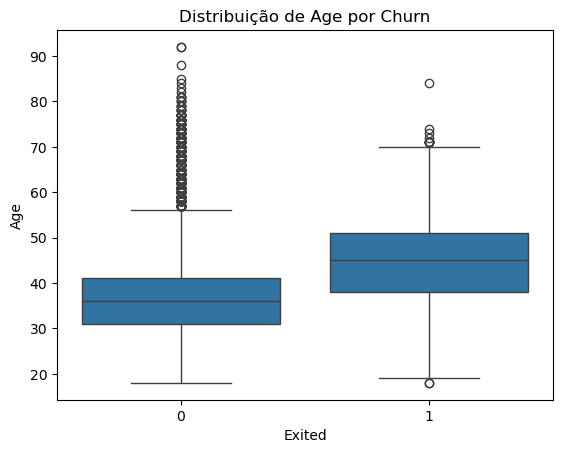

In [17]:
# Variável Age  - avaliada pelas classes de churn
sb.boxplot(x='Exited', y='Age', data=df)
plt.title('Distribuição de Age por Churn')
plt.show()

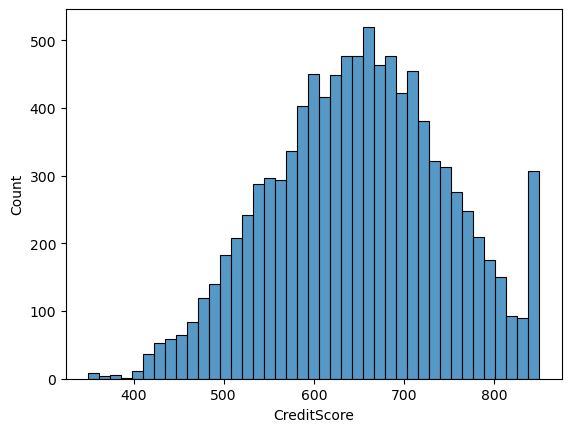

In [19]:
# Variável preditora: CreditScore

sb.histplot(data=df, x="CreditScore");

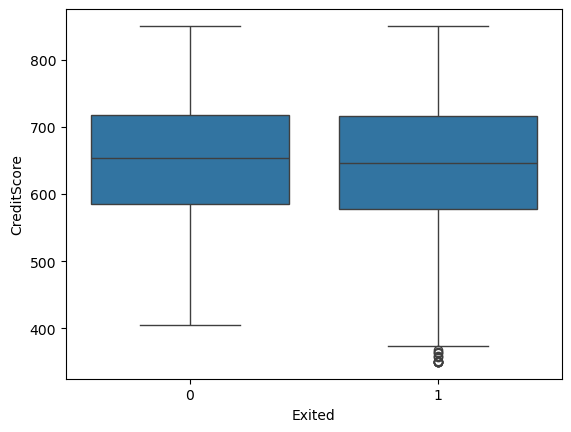

In [21]:
# Variável CreditScore - avaliada pelas classes de churn

sb.boxplot(x='Exited', y='CreditScore', data=df);

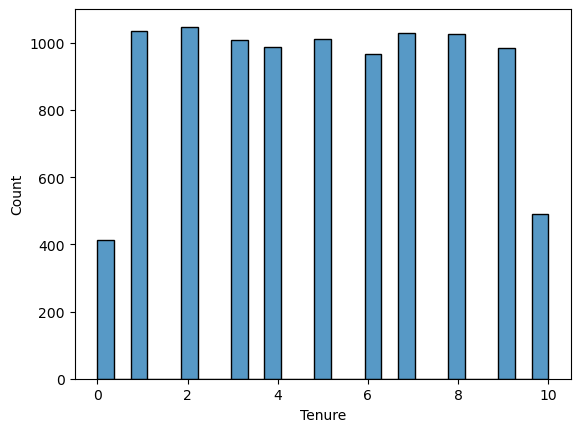

In [23]:
# Variável preditora: Tenure 

sb.histplot(data=df, x="Tenure");

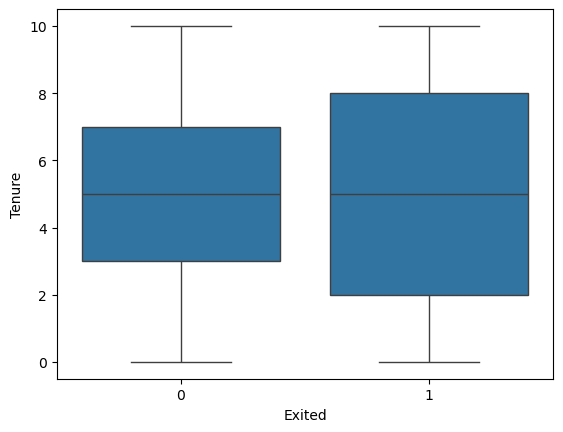

In [25]:
# Variável Tenure - avaliada pelas classes de churn

sb.boxplot(x='Exited', y='Tenure', data=df);

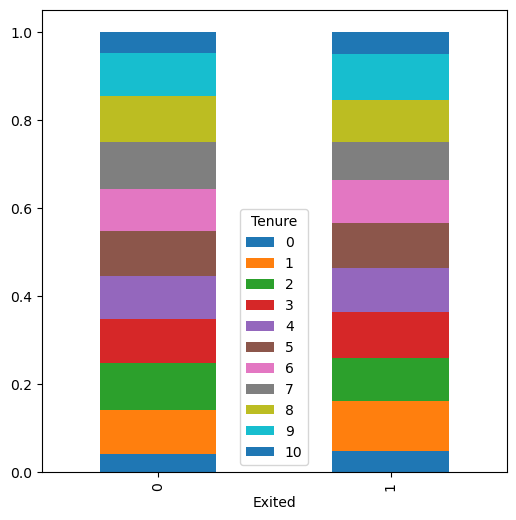

In [27]:
# comparison between HasCrCard and target

Tenure_cat = pd.crosstab(df['Exited'],df['Tenure'])
Tenure_cat.div(Tenure_cat.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(6, 6));

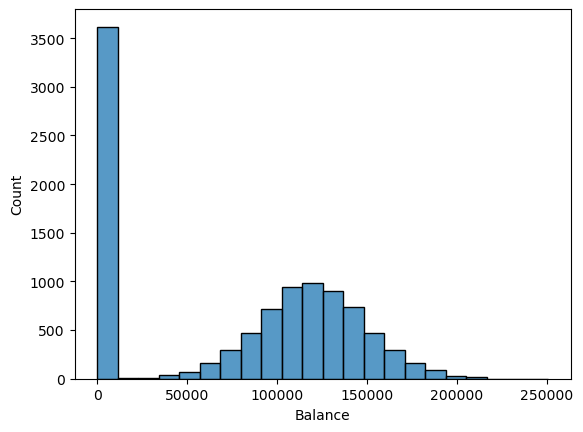

In [29]:
# Balance: Valor de saldo em conta

sb.histplot(data=df, x="Balance");

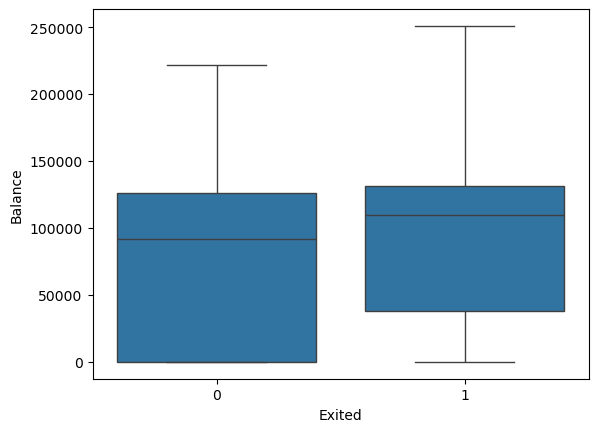

In [31]:
sb.boxplot(x='Exited', y='Balance', data=df, );

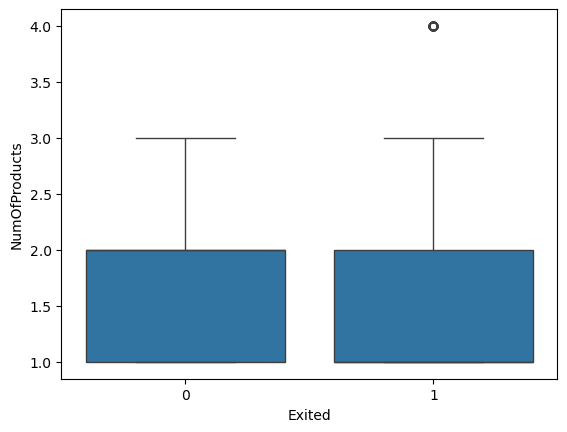

In [33]:
sb.boxplot(x='Exited', y='NumOfProducts', data=df);

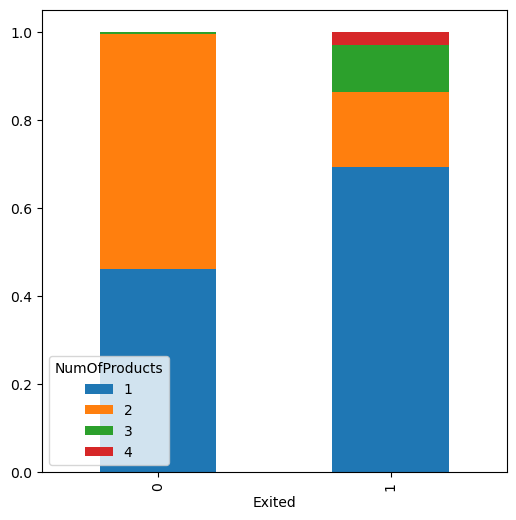

In [35]:
# comparison between NumOfProducts and target

NumOfProducts_cat = pd.crosstab(df['Exited'],df['NumOfProducts'])
NumOfProducts_cat.div(NumOfProducts_cat.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(6, 6));

In [ ]:
# 

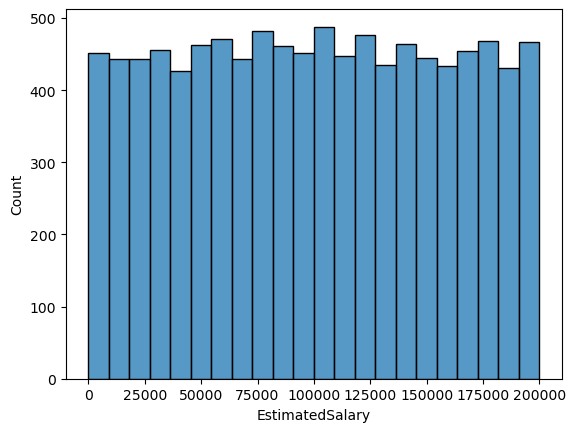

In [37]:
sb.histplot(data=df, x="EstimatedSalary");

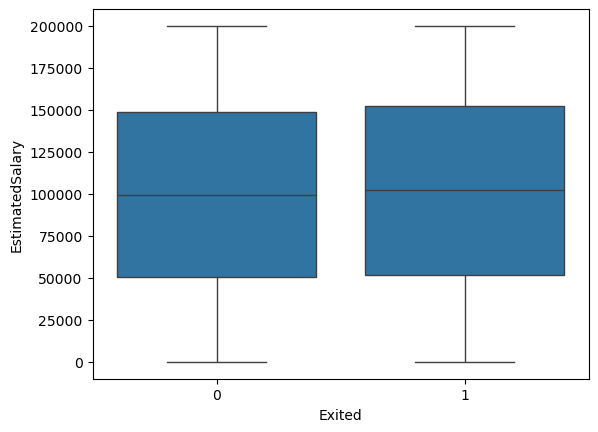

In [39]:
sb.boxplot(x='Exited', y='EstimatedSalary', data=df);

  Continuamos com a avaliação das variáveis preditoras 
  Agora com as variáveis categóricas

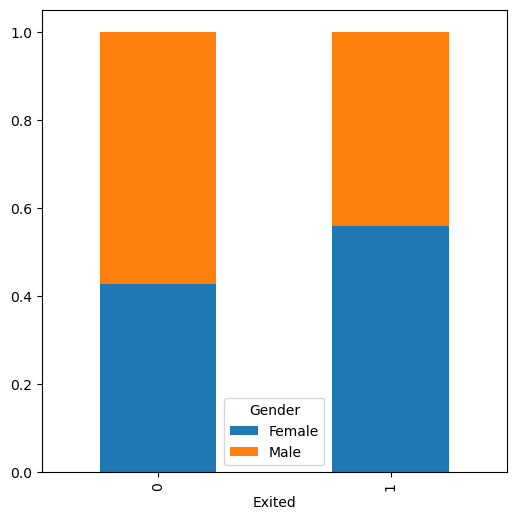

In [41]:
# comparison between Gender and target

Gender_cat = pd.crosstab(df['Exited'],df['Gender'])
Gender_cat.div(Gender_cat.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(6, 6));

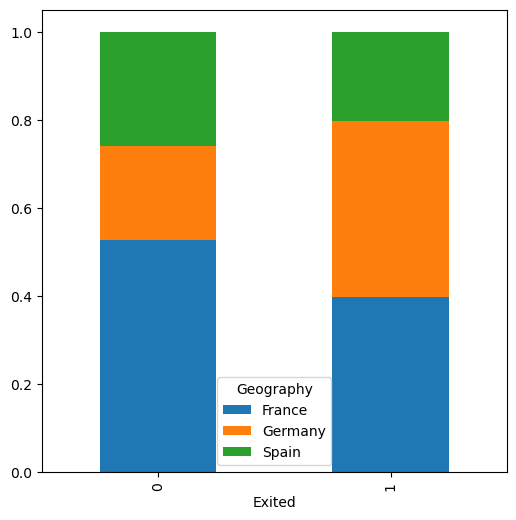

In [43]:
# comparison between Geography and target

Geography_cat = pd.crosstab(df['Exited'],df['Geography'])
Geography_cat.div(Geography_cat.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(6, 6));

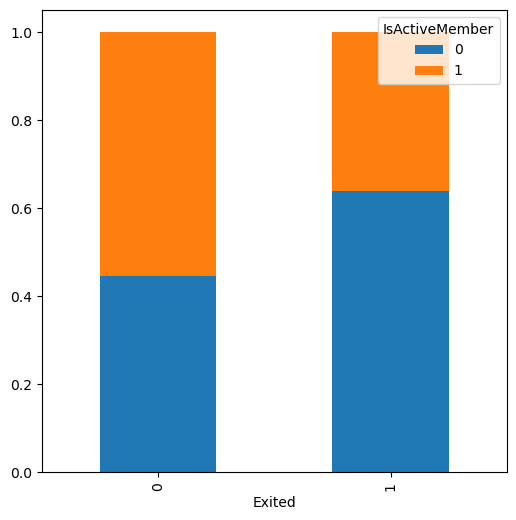

In [45]:
# comparison between IsActiveMember and target

IsActiveMember_cat = pd.crosstab(df['Exited'],df['IsActiveMember'])
IsActiveMember_cat.div(IsActiveMember_cat.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(6, 6));

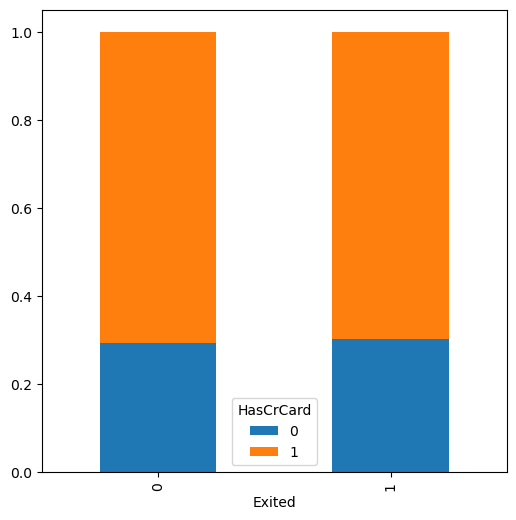

In [47]:
# comparison between HasCrCard and target

HasCrCard_cat = pd.crosstab(df['Exited'],df['HasCrCard'])
HasCrCard_cat.div(HasCrCard_cat.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(6, 6));

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [51]:
# transformando as variveis categoricas 

baseline_df = pd.get_dummies(df, drop_first=True)



In [53]:
baseline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  bool   
 10  Geography_Spain    10000 non-null  bool   
 11  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 732.6 KB


In [55]:
baseline_df.head() 

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [ ]:
# usando diferentes classificadores 
# 1º: Separar o conjunto em variavel resposta e variaveis de treinamento


In [57]:
X = baseline_df[baseline_df.columns.difference(['Exited'])].values
print(X)


[[42 0.0 619 ... 1 1 2]
 [41 83807.86 608 ... 1 1 1]
 [42 159660.8 502 ... 0 3 8]
 ...
 [36 0.0 709 ... 1 1 7]
 [42 75075.31 772 ... 0 2 3]
 [28 130142.79 792 ... 0 1 4]]


In [59]:
y = baseline_df['Exited'].values
print(y)

[1 0 1 ... 1 1 0]


## 1. parte com a presença de desproporcionalidade da  variável target 

#### Relembrando: Neste caso a variável target : Exited (0=não saiu 1=saiu(churn))

In [61]:
# Variável target: "Exited" : Quantos Churn
(df.Exited.value_counts() / df.shape[0]) * 100

Exited
0    79.63
1    20.37
Name: count, dtype: float64

    Holdout  -  Separar a sua base de dados em base de treino e base de teste.
    base de treino (train data) será utilizada para treinar seu modelo.
    base de teste (test data) refere-se à amostra de dados que será utilizada para avaliar o desempenho do seu modelo,
    medindo a capacidade do modelo de generalização (se ele funciona bem em outros dados)


In [63]:
from sklearn.model_selection import train_test_split

# Dividindo os dados em treino e teste:
X_treino, X_teste, y_treino, y_teste = train_test_split(baseline_df.drop('Exited',axis=1),baseline_df['Exited'],test_size=0.3, random_state=17)


In [65]:
X_treino.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,7000.0,650.609571,97.104582,350.00,583.0000,652.000,718.000,850.00
Age,7000.0,38.866000,10.598616,18.00,32.0000,37.000,44.000,92.00
Tenure,7000.0,4.993286,2.895886,0.00,2.0000,5.000,7.000,10.00
Balance,7000.0,76096.896333,62619.261735,0.00,0.0000,96948.895,127646.945,250898.09
NumOfProducts,7000.0,1.530714,0.575913,1.00,1.0000,1.000,2.000,4.00
HasCrCard,7000.0,0.705571,0.455818,0.00,0.0000,1.000,1.000,1.00
IsActiveMember,7000.0,0.510000,0.499936,0.00,0.0000,1.000,1.000,1.00
EstimatedSalary,7000.0,100065.175640,57644.759376,11.58,50776.1175,99823.380,149600.760,199992.48


In [67]:
X_treino.shape, y_treino.shape

((7000, 11), (7000,))

    TÉCNICAS DE TRANSFORMAÇÃO DOS DADOS 
  

    A escala das variáveis pode afetar muito a qualidade das predições.
    Alguns algoritmos darão preferência para utilizar variáveis com valores muito alto.
    
    Normalização Min-Max - transformação, onde os dados de um atributo são normalizados gerando valores  entre  0,0 a 1,0.
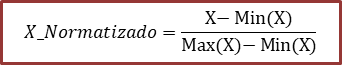
    
    Padronizar as variáveis contínuas para todas terem média de 0 e desvio-padrão de 1.

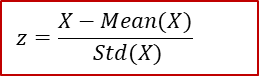

In [69]:
# Feature Scaling 
# Only on Independent Variable 

from sklearn.preprocessing import MinMaxScaler

cols = X_treino.columns

MinMax = MinMaxScaler()

X_treino = MinMax.fit_transform(X_treino)
X_teste = MinMax.transform(X_teste)

X_treino = pd.DataFrame(X_treino, columns=[cols])

In [71]:

X_treino.columns

MultiIndex([(      'CreditScore',),
            (              'Age',),
            (           'Tenure',),
            (          'Balance',),
            (    'NumOfProducts',),
            (        'HasCrCard',),
            (   'IsActiveMember',),
            (  'EstimatedSalary',),
            ('Geography_Germany',),
            (  'Geography_Spain',),
            (      'Gender_Male',)],
           )

In [73]:
X_treino.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,0.374,0.108108,0.7,0.424068,0.000000,0.0,0.0,0.517808,0.0,0.0,1.0
1,0.526,0.310811,0.7,0.000000,0.333333,1.0,0.0,0.301459,0.0,0.0,1.0
2,0.468,0.243243,0.9,0.000000,0.000000,1.0,1.0,0.529085,0.0,0.0,1.0
3,0.492,0.283784,1.0,0.344946,0.000000,0.0,1.0,0.658850,0.0,0.0,0.0
4,0.658,0.567568,0.6,0.000000,0.333333,1.0,1.0,0.386638,0.0,0.0,1.0


In [75]:
X_treino.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,7000.0,0.601219,0.194209,0.0,0.466000,0.604000,0.736000,1.0
Age,7000.0,0.281973,0.143225,0.0,0.189189,0.256757,0.351351,1.0
Tenure,7000.0,0.499329,0.289589,0.0,0.200000,0.500000,0.700000,1.0
Balance,7000.0,0.303298,0.249580,0.0,0.000000,0.386407,0.508760,1.0
NumOfProducts,7000.0,0.176905,0.191971,0.0,0.000000,0.000000,0.333333,1.0
HasCrCard,7000.0,0.705571,0.455818,0.0,0.000000,1.000000,1.000000,1.0
IsActiveMember,7000.0,0.510000,0.499936,0.0,0.000000,1.000000,1.000000,1.0
EstimatedSalary,7000.0,0.500316,0.288251,0.0,0.253847,0.499107,0.748017,1.0
Geography_Germany,7000.0,0.250714,0.433455,0.0,0.000000,0.000000,1.000000,1.0
Geography_Spain,7000.0,0.247286,0.431465,0.0,0.000000,0.000000,0.000000,1.0


In [77]:
y_treino

3796    0
3599    0
7321    0
3748    0
2685    0
       ..
8470    0
6061    1
9529    0
406     1
2191    1
Name: Exited, Length: 7000, dtype: int64

# Quais são alguns tipos de modelo:

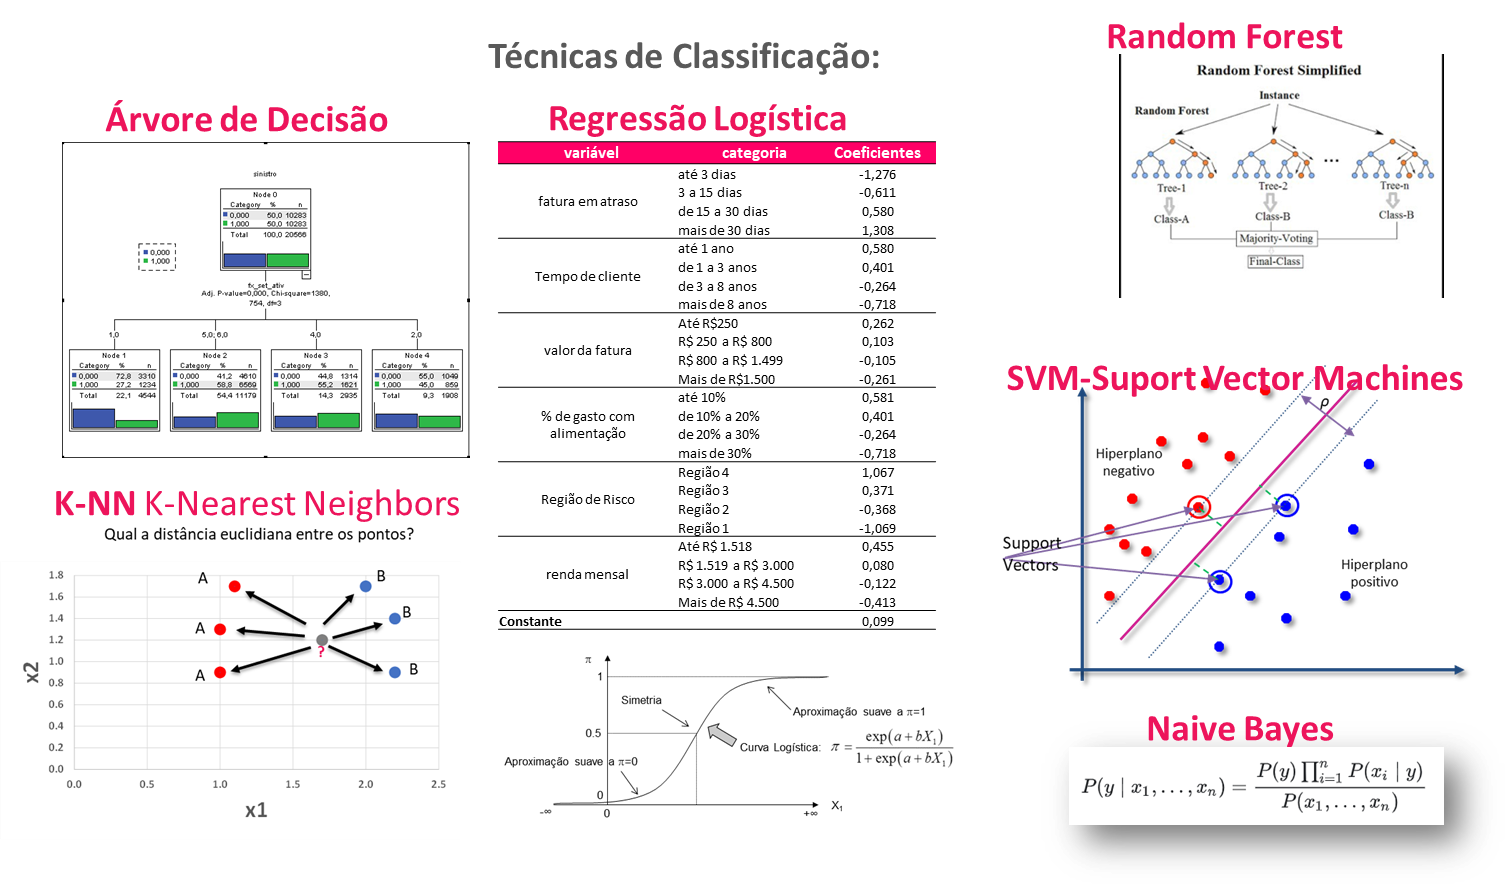

# 1.o MODELO: ÁRVORE DE DECISÃO 

Existem vários algoritmos que podem ser utilizados nessas árvores, dentre eles o ID3, C4.5 e o CART. O foco será esta última abordagem, que é a utilizada pelo scikit-learn. Ela se baseia na separação binária (True | False) de condições utilizando os atributos — features — dos dados.

Esses modelos de aprendizado supervisionado são empregados em tarefas tanto de regressão quanto classificação. O objetivo do método é criar uma árvore que aprende com os dados por meio de regras básicas, chamadas de if-then rules. O modelo identifica qual é o melhor atributo para separar os dados utilizando o critério escolhido, que, neste caso, pode ser entropy ou gini.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

#### Hiperparâmetros



tree = DecisionTreeClassifier(

criterion='gini', # gini vem por default, mas podemos optar por entropy

splitter='best', # a estratégia utilizada para fazer a separação de cada nó 
    # ela também pode ser feita de forma randômica utilizando 'random'
    
max_depth= None, # a máxima profundida que sua árvore de decisão pode ter
    # se for None ela vai buscar a máxima pureza possível
    
min_samples_split = 2, # o mínimo de registros necessários para que uma separação seja feita

min_samples_leaf = 1, # o mínimo de registros necessários em cada nós-folha (veja a primeira imagem)

max_features = None, # o número de atributos que será considerado durante o split
    # None -> seleciona todos os atributos, 'sqrt' -> raiz quadrada do número dos atributos, 'log2' -> log de base 2 do número de atributos
    
max_leaf_nodes=None, # a quantidade máxima de nós-folha que a árvore pode ter
    # se for None ele não limitará o número de nós-folha
    
min_impurity_decrease=0.0, # o split irá ocorrer em cada nó se o decréscimo da impureza foi maior ou igual a este valor

random_state= 42, # permite o notebook ser reproduzível


In [79]:
# Criando modelo 

#Classif_tree = DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
#            max_features='auto', max_leaf_nodes=None,
#            min_impurity_decrease=0.0, 
#             min_samples_leaf=1, min_samples_split=2,
#             min_weight_fraction_leaf=0.0,
#             random_state=None, splitter='best')



Classif_tree = DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=5,
             max_leaf_nodes=None, min_impurity_decrease=0.0, min_samples_leaf=30, min_samples_split=10,
            min_weight_fraction_leaf=0.0, random_state=17, splitter='best')

In [81]:
Classif_tree

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=30,
                       min_samples_split=10, random_state=17)

In [83]:
# Treinando o modelo de arvore de decisão:

Classif_tree.fit(X_treino, y_treino)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=30,
                       min_samples_split=10, random_state=17)

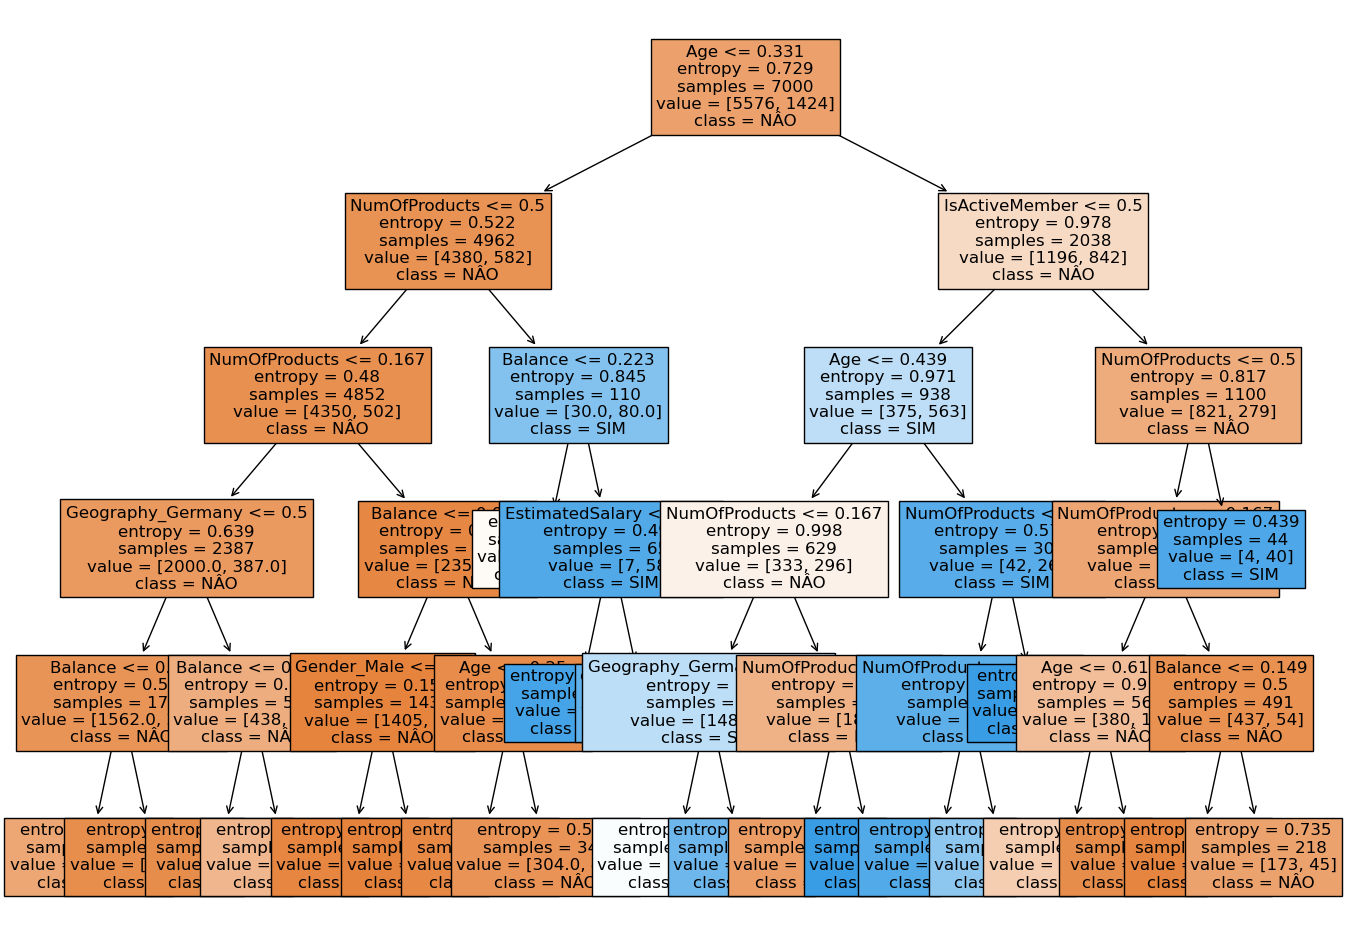

In [85]:
# testando nova saída da árvore com alguns parâmetros de visualização

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,12))
input_features=['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
a = plot_tree(Classif_tree, fontsize=12,filled=True,feature_names=input_features, 
class_names=['NÂO', 'SIM'])  

In [87]:
# Verificando as features mais importantes para o modelo treinado:

for feature,importancia in zip(X_treino.columns,Classif_tree.feature_importances_*100):
    print("{}:{}".format(feature, importancia))  
    

('CreditScore',):0.0
('Age',):41.451606269882525
('Tenure',):0.0
('Balance',):8.570484875505079
('NumOfProducts',):34.10461513113857
('HasCrCard',):0.0
('IsActiveMember',):11.533974597998004
('EstimatedSalary',):0.09266021105256242
('Geography_Germany',):3.605091489220017
('Geography_Spain',):0.0
('Gender_Male',):0.6415674252032476


In [89]:
# criando um dicionário com as variáveis mais importantes para o modelo treinado
dic = {'score':Classif_tree.feature_importances_*100,'features':cols}
#criando um dataframe com os dados
df = pd.DataFrame(dic).sort_values('score',ascending=False)
df

,score,features
1,41.451606,Age
4,34.104615,NumOfProducts
6,11.533975,IsActiveMember
3,8.570485,Balance
8,3.605091,Geography_Germany
10,0.641567,Gender_Male
7,0.092660,EstimatedSalary
0,0.000000,CreditScore
2,0.000000,Tenure
5,0.000000,HasCrCard


In [91]:
# Testando o modelo
y_pred_tree = Classif_tree.predict(X_teste)

In [93]:
y_pred_tree


array([0, 0, 0, ..., 0, 0, 0])

### Avaliação de Desempenho dos Algoritmos

### Matriz de Confusão

In [95]:
from sklearn.metrics import confusion_matrix

confusion_matrix_tree = confusion_matrix(y_true=y_teste, y_pred=y_pred_tree, labels=Classif_tree.classes_) 
confusion_matrix_tree


array([[2298,   89],
       [ 359,  254]])

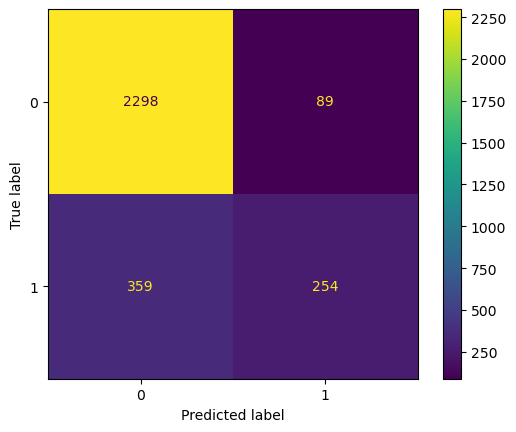

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_tree,
                             display_labels=Classif_tree.classes_)

disp.plot()

 ####  https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
    
    # Resultado do classification_report:
    
    # Precision score = VP/(FP+VP)
    
    # Recall score = VP/(FN+VP)
    
    # F1 Score = 2* Precision Score * Recall Score/ (Precision Score + Recall Score)
        # F1 Score pode ser interpretado como uma média harmônica entre Precision e Recall Score 
        # F1 Score apresenta melhor resultado quando o valor é 1 e pior escore em 0.

In [105]:
#classification_report:

print(classification_report(y_teste, y_pred_tree))

# Resultado do classification_report:

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2387
           1       0.74      0.41      0.53       613

    accuracy                           0.85      3000
   macro avg       0.80      0.69      0.72      3000
weighted avg       0.84      0.85      0.83      3000



# 2.o MODELO: REGRESSÃO LOGÍSTICA

     Modelo de Regressão Logística
        G = a+ B1 X1 + B2 X2 + ...+ Bn Xn
        G: logit da resposta de preferência (sim) a : 
        Intersecção B1, B2, ...,Bn : coeficientes logísticos
 

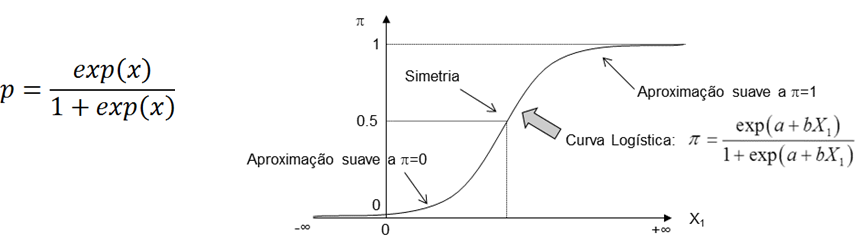

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


A penalização L2 é conhecida como penalização Ridge.
O objetivo é buscar minimizar o erro e o tamanho dos parâmetros.
A penalização ridge encolhe os parâmetros, mas não reduz nenhum a 0, não faz seleção de variáveis.
Para isso, existe a penalização Lasso (L1).

In [101]:
# logreg = LogisticRegression(penalty='none',random_state=17)

logreg = LogisticRegression(penalty='l2',random_state=17)



In [103]:
logreg

LogisticRegression(random_state=17)

In [107]:
#Em seguida, você precisa treinar o seu modelo. Precisamos rodar a regressão para X_train e y_train:

# treina o modelo
logistica = logreg.fit(X_treino, y_treino)  #fitting the model 

In [109]:
print(logistica.coef_) 

[[-0.47536191  5.09613797 -0.13686954  0.59348936 -0.4594614  -0.06138087
  -1.11785709  0.15192658  0.77315518  0.01525698 -0.51348849]]


In [111]:
cols

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [113]:
# Os coeficientes do modelo (b1,b2,b3....)

coefficients = pd.concat([pd.DataFrame(cols),pd.DataFrame(np.transpose(logistica.coef_))], axis = 1)
coefficients

,0,0
0,CreditScore,-0.475362
1,Age,5.096138
2,Tenure,-0.136870
3,Balance,0.593489
4,NumOfProducts,-0.459461
5,HasCrCard,-0.061381
6,IsActiveMember,-1.117857
7,EstimatedSalary,0.151927
8,Geography_Germany,0.773155
9,Geography_Spain,0.015257


In [115]:
# faz predicao e salva em y_pred
 
y_pred_log = logistica.predict(X_teste)
y_pred_log

array([0, 0, 0, ..., 0, 0, 0])

In [117]:
# acuracia
logistica.score(X_teste, y_teste)

0.8083333333333333

In [119]:
# matriz de confusao
from sklearn.metrics import confusion_matrix

confusion_matrix_log = confusion_matrix(y_teste, y_pred_log)
confusion_matrix_log

array([[2309,   78],
       [ 497,  116]])

In [121]:
print(classification_report(y_teste, logistica.predict(X_teste)))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      2387
           1       0.60      0.19      0.29       613

    accuracy                           0.81      3000
   macro avg       0.71      0.58      0.59      3000
weighted avg       0.78      0.81      0.77      3000



## 2. parte: Balanceamento da variável target  

#### A base de dados está desbalanceada com relação ao target.

    Para diminuir as chances de ter uma análise com viés, vamos separar registros com base na ocorrência de target == True.

    Métodos baseados em amostragem (sampling, ou resampling): 
    são os métodos mais simples e mais antigos utilizados para o balanceamento de conjuntos de dados.
    Eles consistem na modificação da estrutura do conjunto de dados desbalanceado, de maneira a deixá-lo com quantidades equivalentes de amostras para as classes presentes, seja através da remoção (undersampling) ou adição (oversampling) de novas amostras.

    Vamos verificar uma opção!!!!

In [123]:
baseline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  bool   
 10  Geography_Spain    10000 non-null  bool   
 11  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 732.6 KB


In [125]:
### Separar classe minoritária e maioritária
df_minor  = baseline_df[baseline_df['Exited']==True]
df_maior = baseline_df[baseline_df['Exited']==False]                                                                                          

In [127]:
df_minor

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
5,645,44,8,113755.78,2,1,0,149756.71,1,False,True,True
7,376,29,4,115046.74,4,1,0,119346.88,1,True,False,False
16,653,58,1,132602.88,1,1,0,5097.67,1,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9981,498,42,3,152039.70,1,1,1,53445.17,1,True,False,True
9982,655,46,7,137145.12,1,1,0,115146.40,1,True,False,False
9991,597,53,4,88381.21,1,1,0,69384.71,1,False,False,False
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False


In [129]:
df_maior

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
6,822,50,7,0.00,2,1,1,10062.80,0,False,False,True
8,501,44,4,142051.07,2,0,1,74940.50,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9993,644,28,7,155060.41,1,1,0,29179.52,0,False,False,True
9994,800,29,2,0.00,2,0,0,167773.55,0,False,False,False
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True


In [131]:
### Selecionar uma amostra da classe maioritária com base no tamanho da classe minoritária
df_maior = df_maior.sample(len(df_minor), random_state=17)

In [133]:
df_maior

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
2476,451,38,9,61482.47,1,1,1,167538.66,0,True,False,False
8085,794,33,0,0.00,2,0,0,178122.71,0,False,False,True
1293,641,30,2,87505.47,2,0,1,7278.57,0,False,False,True
9611,608,37,2,130461.02,1,1,0,21967.15,0,False,True,True
8601,640,45,8,120591.19,1,0,0,195123.94,0,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1680,705,39,6,133261.13,1,1,1,78065.90,0,False,True,True
8751,575,30,8,0.00,2,1,0,185341.63,0,False,True,False
6940,575,46,1,0.00,2,1,1,65998.26,0,False,False,True
4279,604,33,3,148659.48,1,0,0,42437.75,0,False,False,True


In [135]:
### concatenar as classes maioritária e minoritária e renomear a base para clientes_sample
clientes_sample = pd.concat([df_maior,df_minor])

In [137]:
clientes_sample

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
2476,451,38,9,61482.47,1,1,1,167538.66,0,True,False,False
8085,794,33,0,0.00,2,0,0,178122.71,0,False,False,True
1293,641,30,2,87505.47,2,0,1,7278.57,0,False,False,True
9611,608,37,2,130461.02,1,1,0,21967.15,0,False,True,True
8601,640,45,8,120591.19,1,0,0,195123.94,0,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9981,498,42,3,152039.70,1,1,1,53445.17,1,True,False,True
9982,655,46,7,137145.12,1,1,0,115146.40,1,True,False,False
9991,597,53,4,88381.21,1,1,0,69384.71,1,False,False,False
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False


In [139]:

## embaralhar a amostra
clientes_sample = clientes_sample.sample(frac=1, random_state=17)

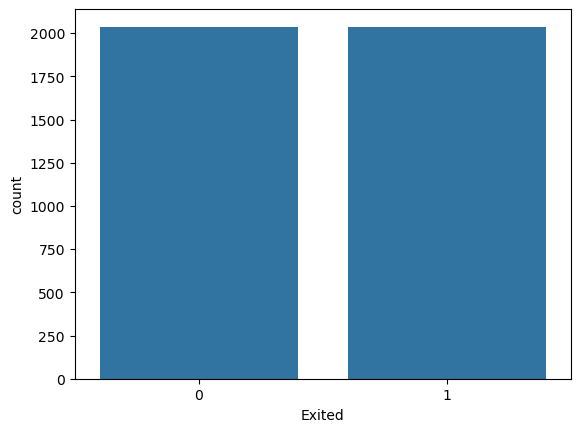

In [141]:
### Verificar se a base está balanceada
sb.countplot(x='Exited', data=clientes_sample);

In [143]:
# separar dados em treino e teste
# Dividindo os dados em treino e teste:
X = clientes_sample.drop('Exited', axis=1)
y = clientes_sample['Exited'].astype('int')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

In [145]:
# Feature Scaling 
# Only on Independent Variable 

from sklearn.preprocessing import MinMaxScaler

cols = X_train.columns

MinMax = MinMaxScaler()
X_train = MinMax.fit_transform(X_train)
X_test = MinMax.transform(X_test)
X_train = pd.DataFrame(X_train, columns=[cols])
X_train.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,0.606,0.424242,0.0,0.501520,0.000000,1.0,0.0,0.391484,0.0,0.0,1.0
1,0.850,0.181818,0.4,0.000000,0.333333,1.0,0.0,0.246815,0.0,0.0,1.0
2,0.450,0.590909,0.8,0.578625,0.000000,1.0,1.0,0.422632,0.0,0.0,0.0
3,0.520,0.242424,0.0,0.432523,0.000000,0.0,0.0,0.628644,0.0,0.0,1.0
4,0.710,0.318182,0.8,0.604488,0.000000,1.0,1.0,0.058397,0.0,1.0,0.0


In [147]:
# Árvore de Decisão  amostra balanceada

Classif_tree = DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=5,
         max_leaf_nodes=None,
            min_impurity_decrease=0.0, 
            min_samples_leaf=20, min_samples_split=10,
            min_weight_fraction_leaf=0.0,
            random_state=17, splitter='best')


In [149]:
Classif_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=20,
                       min_samples_split=10, random_state=17)

In [151]:
y_pred_tree = Classif_tree.predict(X_test)

In [153]:
# Matriz de confusão
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test, y_pred_tree)
confusion_matrix

array([[414, 204],
       [100, 505]])

In [155]:
# classification_report:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.81      0.67      0.73       618
           1       0.71      0.83      0.77       605

    accuracy                           0.75      1223
   macro avg       0.76      0.75      0.75      1223
weighted avg       0.76      0.75      0.75      1223



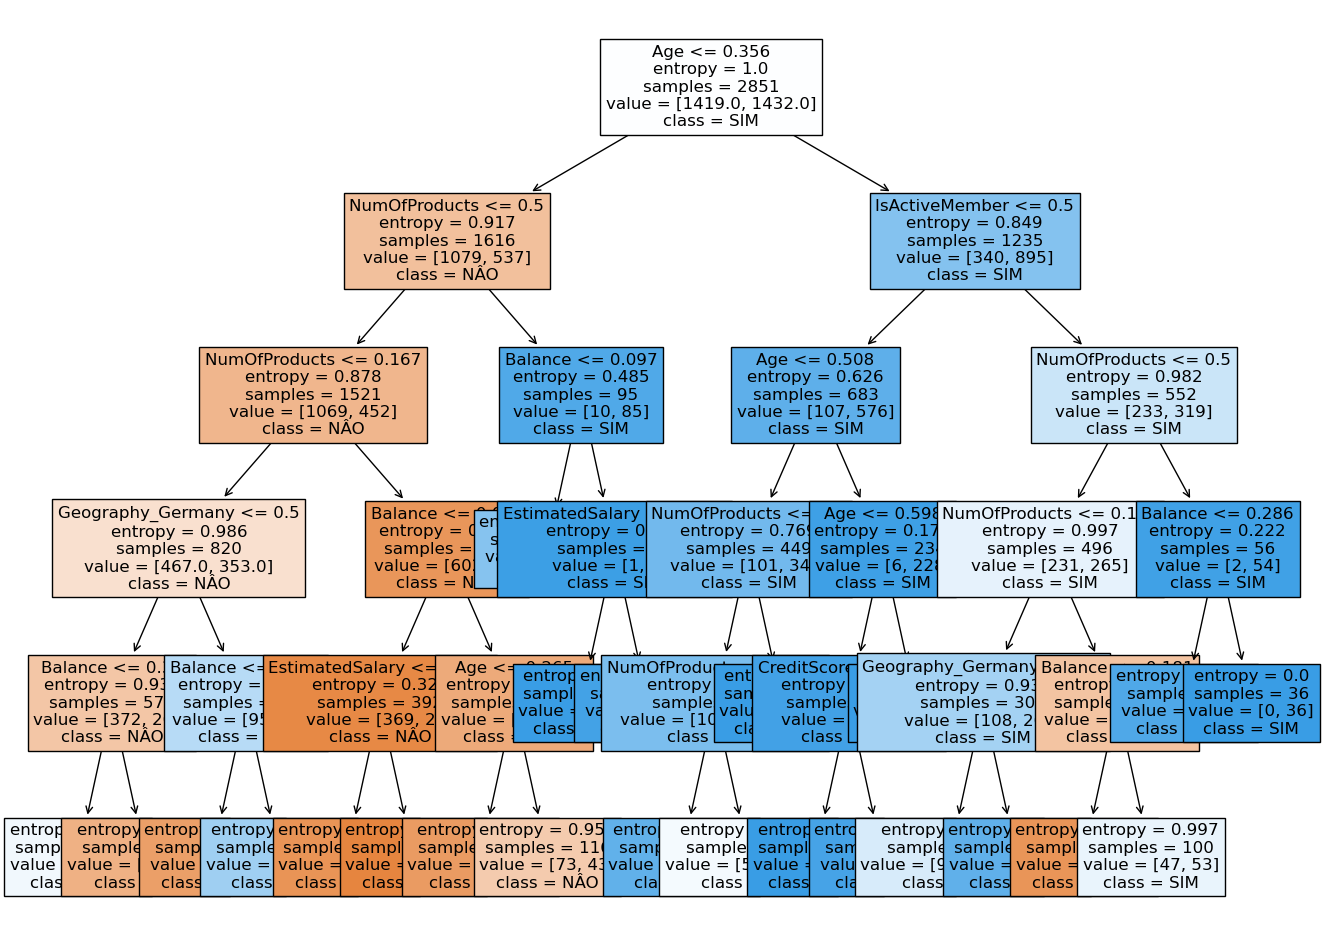

In [157]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(16,12))
input_features=['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
a = plot_tree(Classif_tree, fontsize=12,filled=True,feature_names=input_features, 
class_names=['NÂO', 'SIM']) 

#### Regressão Logística amostra balanceada

In [159]:
logreg = LogisticRegression(penalty='l2',random_state=17)
# treina o modelo
logistic = logreg.fit(X_train, y_train)  #fitting the model 
print(logistic.coef_)


[[-0.63908814  4.91758673 -0.14837916  0.77499925 -0.05793382 -0.11087124
  -0.95399242 -0.0220933   0.82652359  0.11172628 -0.5378421 ]]


In [161]:
y_pred_log = logistic.predict(X_test)

In [163]:
y_pred_log 

array([1, 1, 1, ..., 0, 0, 0])

In [165]:
y_test

6775    1
2879    1
7837    1
5907    0
6030    0
       ..
4447    1
3803    1
9219    0
9340    0
7314    1
Name: Exited, Length: 1223, dtype: int64

In [167]:
# Matriz de confusão
from sklearn.metrics import confusion_matrix

confusion_matrix_log = confusion_matrix(y_test,logistic.predict(X_test))
confusion_matrix_log


array([[433, 185],
       [181, 424]])

In [169]:

print(classification_report(y_test, logistic.predict(X_test)))

              precision    recall  f1-score   support

           0       0.71      0.70      0.70       618
           1       0.70      0.70      0.70       605

    accuracy                           0.70      1223
   macro avg       0.70      0.70      0.70      1223
weighted avg       0.70      0.70      0.70      1223



#### Qual Algoritmo ? Qual método de Amostragem?

#### Balanceamento de amostras:
A Re-amostragem é uma técnica comumente utilizada para lidar com o desbalanceamento de dados em problemas de aprendizado de máquina. Essa técnica tem como objetivo pré-processar os dados de treinamento para minimizar a discrepância entre as classes, modificando as distribuições no conjunto de treinamento.

Existem duas técnicas de amostragem: undersampling e oversampling.

Técnica de undersampling consiste em remover exemplos da classe majoritária para tornar a proporção entre as classes mais equilibrada. Essa técnica é adequada para aplicações em larga escala, onde o número de amostras majoritárias é muito grande. No entanto, é importante observar que descartar dados pode levar à perda de instâncias informativas da classe majoritária e degradar o desempenho do classificador.

Técnica de oversampling aumenta o número de instâncias minoritárias replicando-as, isto é, gerar novos exemplos para a classe minoritária, de forma a aumentar sua representatividade no conjunto de dados.
Nesse caso, não há perda de informação, mas criar novos dados pode levar a um custo computacional maior (Chawla et al., 2004). Além disso, se algumas amostras de classes pequenas contiverem erros, adicioná-los irá deteriorar o desempenho da classificação na classe minoritária.
